# Angle and Norm Experiment

For a fixed setup $(w^*, \Sigma, n, d)$, run GD and plot:
- $\text{angle}(w_t, w^*)$ over time
- $\big|\|w_t\| - \|w^*\|\big|$ over time

Goal: visually identify whether $\arg\min_t \text{angle}(w_t, w^*)$ and $\arg\min_t |\|w_t\| - \|w^*\||$ coincide.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from model import OverparameterizedLogisticRegression

## Setup

In [2]:
model = OverparameterizedLogisticRegression(d=2000, n=1000, k=100, seed=42)
model.generate_data()

Parameters: d=2000, n=1000, k=100
tr(Sigma) = 1.6444
eta (used) = 0.188748
Data generated: X shape = (1000, 2000), y shape = (1000,)
Label balance: 49.10% positive


## Run GD

In [ ]:
T = 50000
model.run_gd(T)

  t=       0: loss=0.693147, ||w||=0.0000
Continuing GD from t=0 to t=50000...
  t=    2000: loss=0.567178, ||w||=3.2518
  t=    4000: loss=0.560702, ||w||=4.4812
  t=    6000: loss=0.556337, ||w||=5.5191
  t=    8000: loss=0.552808, ||w||=6.4740


## Plot: Angle and Norm Difference

In [ ]:
w_star_norm = norm(model.w_star)
w_star_dir = model.w_star / w_star_norm

times, angles, norm_diffs = [], [], []

for t, w in model.w_history:
    if t == 0:
        continue
    wn = norm(w)
    cos_sim = np.dot(w / wn, w_star_dir)
    cos_sim = np.clip(cos_sim, -1, 1)
    times.append(t)
    angles.append(np.degrees(np.arccos(cos_sim)))
    norm_diffs.append(abs(wn - w_star_norm))

times = np.array(times)
angles = np.array(angles)
norm_diffs = np.array(norm_diffs)

argmin_angle = times[np.argmin(angles)]
argmin_norm  = times[np.argmin(norm_diffs)]

print(f'argmin angle:     t = {argmin_angle}')
print(f'argmin norm diff: t = {argmin_norm}')

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Top: angle(w_t, w*) ---
ax1.semilogx(times, angles, color='steelblue', linewidth=1.5)
ax1.axvline(argmin_angle, color='steelblue', linestyle='--', linewidth=1.2,
            label=f'argmin t = {argmin_angle}')
ax1.set_ylabel(r'angle$(w_t,\; w^*)$ [degrees]')
ax1.set_title(r'Angle between $w_t$ and $w^*$')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Bottom: |||w_t|| - ||w*||| ---
ax2.semilogx(times, norm_diffs, color='darkorange', linewidth=1.5)
ax2.axvline(argmin_norm, color='darkorange', linestyle='--', linewidth=1.2,
            label=f'argmin t = {argmin_norm}')
ax2.set_xlabel('GD iteration t (log scale)')
ax2.set_ylabel(r'$|\|w_t\| - \|w^*\||$')
ax2.set_title(r'Norm difference $|\|w_t\| - \|w^*\||$')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('angle_and_norm_experiment.png', dpi=150)
plt.show()

In [ ]:
# Compute w_tilde if not already done
if model.w_tilde is None:
    model.compute_max_margin_direction()

T_MAX = 30000

w_star_norm = norm(model.w_star)
w_star_dir = model.w_star / w_star_norm

times2, angles2, norm_diffs2, cos_wstar2, cos_wtilde2 = [], [], [], [], []

for t, w in model.w_history:
    if t == 0 or t > T_MAX:
        continue
    wn = norm(w)
    w_dir = w / wn
    cos_s = np.dot(w_dir, w_star_dir)
    cos_t = np.dot(w_dir, model.w_tilde)

    times2.append(t)
    cos_wstar2.append(cos_s)
    cos_wtilde2.append(cos_t)
    angles2.append(np.degrees(np.arccos(np.clip(cos_s, -1, 1))))
    norm_diffs2.append(abs(wn - w_star_norm))

times2      = np.array(times2)
angles2     = np.array(angles2)
norm_diffs2 = np.array(norm_diffs2)
cos_wstar2  = np.array(cos_wstar2)
cos_wtilde2 = np.array(cos_wtilde2)

argmin_angle     = times2[np.argmin(angles2)]
argmin_norm      = times2[np.argmin(norm_diffs2)]
argmax_coswstar  = times2[np.argmax(cos_wstar2)]
argmax_coswtilde = times2[np.argmax(cos_wtilde2)]

print(f'argmin angle:          t = {argmin_angle}')
print(f'argmin norm diff:      t = {argmin_norm}')
print(f'argmax cos(w_t, w*):   t = {argmax_coswstar}')
print(f'argmax cos(w_t, w~):   t = {argmax_coswtilde}')

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# 1. Angle(w_t, w*)
ax = axes[0]
ax.semilogx(times2, angles2, color='steelblue', linewidth=1.5)
ax.axvline(argmin_angle, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_angle}')
ax.set_ylabel(r'angle$(w_t, w^*)$ [deg]')
ax.set_title(r'Angle between $w_t$ and $w^*$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2. Norm difference
ax = axes[1]
ax.semilogx(times2, norm_diffs2, color='darkorange', linewidth=1.5)
ax.axvline(argmin_norm, color='darkorange', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_norm}')
ax.set_ylabel(r'$|\|w_t\| - \|w^*\||$')
ax.set_title(r'Norm difference $|\|w_t\| - \|w^*\||$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 3. cos(w_t/||w_t||, w*/||w*||)
ax = axes[2]
ax.semilogx(times2, cos_wstar2, color='mediumseagreen', linewidth=1.5)
ax.axvline(argmax_coswstar, color='mediumseagreen', linestyle='--', linewidth=1.2,
           label=f'argmax t = {argmax_coswstar}')
ax.set_ylabel(r'$\cos(w_t/\|w_t\|,\; w^*/\|w^*\|)$')
ax.set_title(r'Cosine similarity to $w^*$ direction')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4. cos(w_t/||w_t||, w_tilde)
ax = axes[3]
ax.semilogx(times2, cos_wtilde2, color='mediumpurple', linewidth=1.5)
ax.axvline(argmax_coswtilde, color='mediumpurple', linestyle='--', linewidth=1.2,
           label=f'argmax t = {argmax_coswtilde}')
ax.set_ylabel(r'$\cos(w_t/\|w_t\|,\; \tilde{w})$')
ax.set_title(r'Cosine similarity to $\tilde{w}$ (max-margin direction)')
ax.set_xlabel('GD iteration t (log scale)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'All quantities up to t={T_MAX}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('angle_and_norm_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

argmin angle(w_t, w*):    t = 3298
argmin norm diff:          t = 16000
argmin angle(w_t, w~):    t = 50000


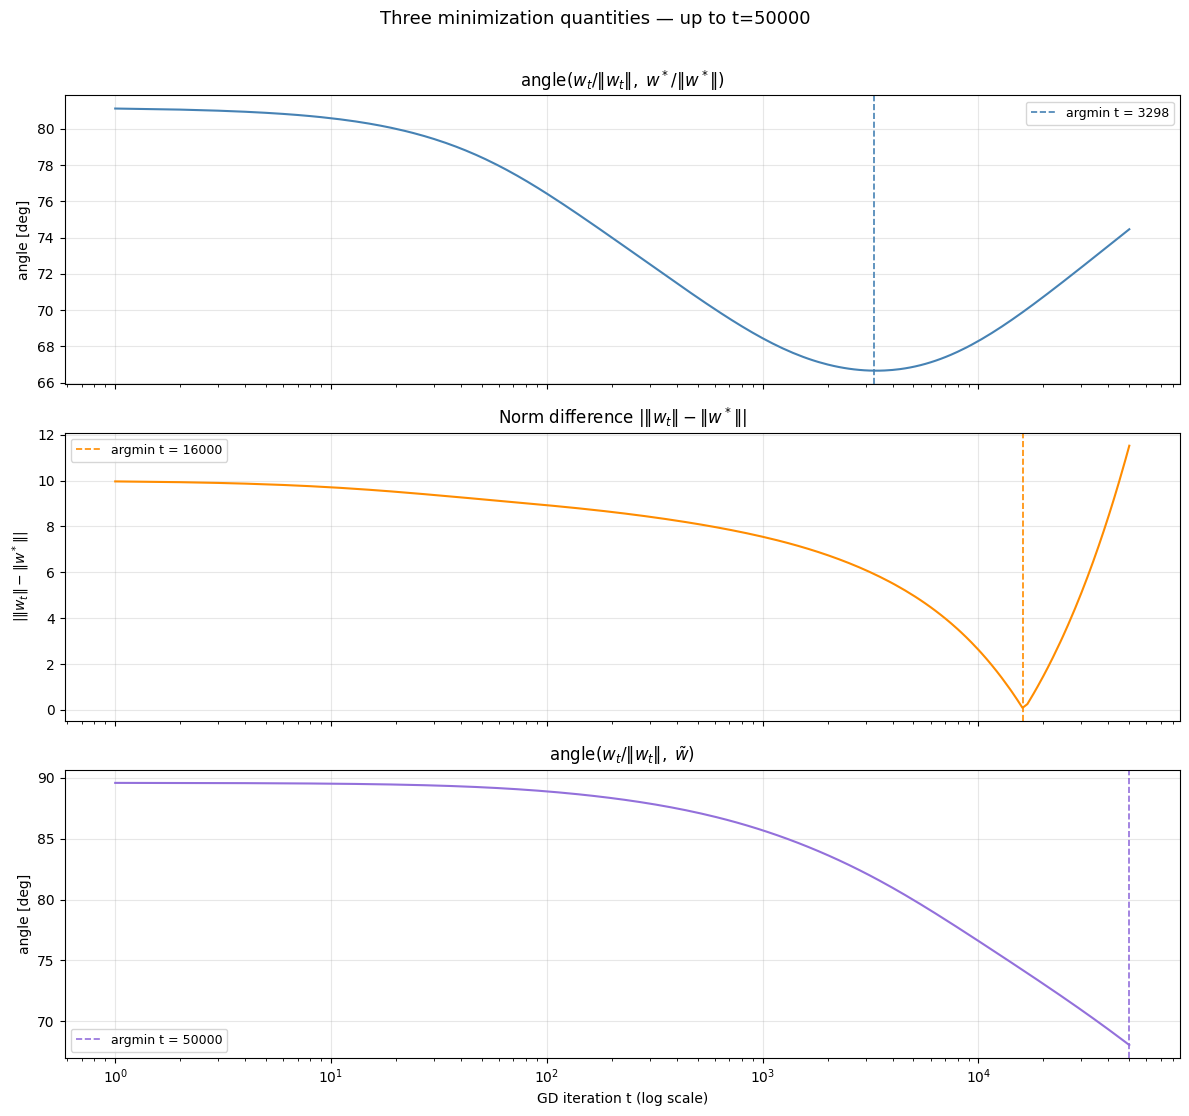

In [15]:
# Transform cos -> angle for w_tilde, compute argmin
angle_wtilde2 = np.degrees(np.arccos(np.clip(cos_wtilde2, -1, 1)))
argmin_angle_wtilde = times2[np.argmin(angle_wtilde2)]

print(f'argmin angle(w_t, w*):    t = {argmin_angle}')
print(f'argmin norm diff:          t = {argmin_norm}')
print(f'argmin angle(w_t, w~):    t = {argmin_angle_wtilde}')

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# 1. angle(w_t/||w_t||, w*/||w*||)
ax = axes[0]
ax.semilogx(times2, angles2, color='steelblue', linewidth=1.5)
ax.axvline(argmin_angle, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_angle}')
ax.set_ylabel('angle [deg]')
ax.set_title(r'angle$(w_t/\|w_t\|,\; w^*/\|w^*\|)$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2. |||w_t|| - ||w*|||
ax = axes[1]
ax.semilogx(times2, norm_diffs2, color='darkorange', linewidth=1.5)
ax.axvline(argmin_norm, color='darkorange', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_norm}')
ax.set_ylabel(r'$|\|w_t\| - \|w^*\||$')
ax.set_title(r'Norm difference $|\|w_t\| - \|w^*\||$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 3. angle(w_t/||w_t||, w_tilde)
ax = axes[2]
ax.semilogx(times2, angle_wtilde2, color='mediumpurple', linewidth=1.5)
ax.axvline(argmin_angle_wtilde, color='mediumpurple', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_angle_wtilde}')
ax.set_ylabel('angle [deg]')
ax.set_title(r'angle$(w_t/\|w_t\|,\; \tilde{w})$')
ax.set_xlabel('GD iteration t (log scale)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'Three minimization quantities — up to t={T_MAX}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('angle_and_norm_experiment_3panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def normalize(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr - lo

fig, ax = plt.subplots(figsize=(12, 5))

ax.semilogx(times2, normalize(angles2),       color='steelblue',  linewidth=1.5, label=r'angle$(w_t/\|w_t\|,\; w^*/\|w^*\|)$ [normalized]')
ax.semilogx(times2, normalize(norm_diffs2),   color='darkorange', linewidth=1.5, label=r'$|\|w_t\| - \|w^*\||$ [normalized]')
ax.semilogx(times2, normalize(angle_wtilde2), color='mediumpurple', linewidth=1.5, label=r'angle$(w_t/\|w_t\|,\; \tilde{w})$ [normalized]')

ax.axvline(argmin_angle,        color='steelblue',   linestyle='--', linewidth=1.0, alpha=0.7)
ax.axvline(argmin_norm,         color='darkorange',  linestyle='--', linewidth=1.0, alpha=0.7)
ax.axvline(argmin_angle_wtilde, color='mediumpurple', linestyle='--', linewidth=1.0, alpha=0.7)

ax.set_xlabel('GD iteration t (log scale)')
ax.set_ylabel('Normalized value [0, 1]')
ax.set_title(f'Three minimization quantities normalized to [0, 1] — up to t={T_MAX}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('angle_and_norm_experiment_merged.png', dpi=150)
plt.show()

In [3]:
# Cell A: new model, run GD for T=50k
model2 = OverparameterizedLogisticRegression(d=2000, n=1000, k=100, seed=123)
model2.generate_data()
model2.run_gd(50000)

Parameters: d=2000, n=1000, k=100
tr(Sigma) = 1.6444
eta (used) = 0.188748
Data generated: X shape = (1000, 2000), y shape = (1000,)
Label balance: 50.70% positive
  t=       0: loss=0.693147, ||w||=0.0000
Continuing GD from t=0 to t=50000...
  t=    2000: loss=0.551449, ||w||=2.9523
  t=    4000: loss=0.546186, ||w||=3.9756
  t=    6000: loss=0.542303, ||w||=4.9600
  t=    8000: loss=0.539163, ||w||=5.8921
  t=   10000: loss=0.536498, ||w||=6.7718
  t=   12000: loss=0.534165, ||w||=7.6053
  t=   14000: loss=0.532073, ||w||=8.3994
  t=   16000: loss=0.530165, ||w||=9.1603
  t=   18000: loss=0.528400, ||w||=9.8933
  t=   20000: loss=0.526751, ||w||=10.6025
  t=   22000: loss=0.525196, ||w||=11.2913
  t=   24000: loss=0.523720, ||w||=11.9627
  t=   26000: loss=0.522312, ||w||=12.6189
  t=   28000: loss=0.520961, ||w||=13.2618
  t=   30000: loss=0.519661, ||w||=13.8928
  t=   32000: loss=0.518405, ||w||=14.5134
  t=   34000: loss=0.517190, ||w||=15.1246
  t=   36000: loss=0.516010, ||w||=

In [4]:
# Cell B: compute all quantities for model2
if model2.w_tilde is None:
    model2.compute_max_margin_direction()

T_MAX2 = 50000

w_star_norm2 = norm(model2.w_star)
w_star_dir2  = model2.w_star / w_star_norm2

times3, angles3, norm_diffs3, cos_wtilde3 = [], [], [], []

for t, w in model2.w_history:
    if t == 0 or t > T_MAX2:
        continue
    wn = norm(w)
    w_dir = w / wn
    cos_s = np.dot(w_dir, w_star_dir2)
    cos_t = np.dot(w_dir, model2.w_tilde)

    times3.append(t)
    angles3.append(np.degrees(np.arccos(np.clip(cos_s, -1, 1))))
    norm_diffs3.append(abs(wn - w_star_norm2))
    cos_wtilde3.append(cos_t)

times3        = np.array(times3)
angles3       = np.array(angles3)
norm_diffs3   = np.array(norm_diffs3)
angle_wtilde3 = np.degrees(np.arccos(np.clip(np.array(cos_wtilde3), -1, 1)))

argmin_angle3        = times3[np.argmin(angles3)]
argmin_norm3         = times3[np.argmin(norm_diffs3)]
argmin_angle_wtilde3 = times3[np.argmin(angle_wtilde3)]

print(f'argmin angle(w_t, w*):    t = {argmin_angle3}')
print(f'argmin norm diff:          t = {argmin_norm3}')
print(f'argmin angle(w_t, w~):    t = {argmin_angle_wtilde3}')

Max-margin SVM solved. Min margin = 0.999705
Support vectors (alpha > 1e-6): 610
argmin angle(w_t, w*):    t = 3124
argmin norm diff:          t = 18000
argmin angle(w_t, w~):    t = 50000


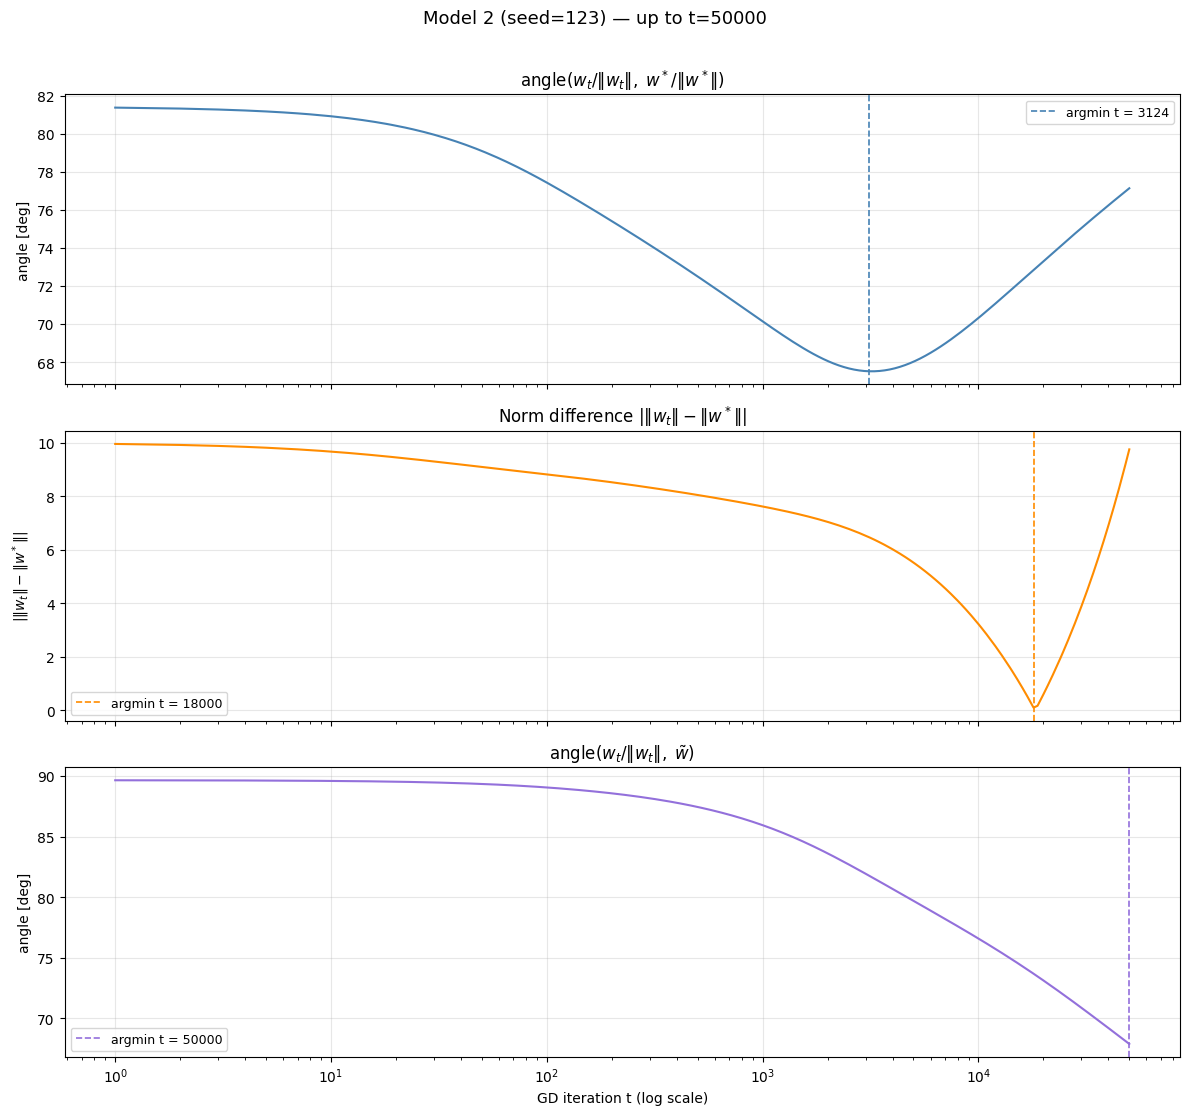

In [5]:
# Cell C: 3-panel plot for model2
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

ax = axes[0]
ax.semilogx(times3, angles3, color='steelblue', linewidth=1.5)
ax.axvline(argmin_angle3, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_angle3}')
ax.set_ylabel('angle [deg]')
ax.set_title(r'angle$(w_t/\|w_t\|,\; w^*/\|w^*\|)$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(times3, norm_diffs3, color='darkorange', linewidth=1.5)
ax.axvline(argmin_norm3, color='darkorange', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_norm3}')
ax.set_ylabel(r'$|\|w_t\| - \|w^*\||$')
ax.set_title(r'Norm difference $|\|w_t\| - \|w^*\||$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.semilogx(times3, angle_wtilde3, color='mediumpurple', linewidth=1.5)
ax.axvline(argmin_angle_wtilde3, color='mediumpurple', linestyle='--', linewidth=1.2,
           label=f'argmin t = {argmin_angle_wtilde3}')
ax.set_ylabel('angle [deg]')
ax.set_title(r'angle$(w_t/\|w_t\|,\; \tilde{w})$')
ax.set_xlabel('GD iteration t (log scale)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'Model 2 (seed=123) — up to t={T_MAX2}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('angle_and_norm_model2_3panel.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'angle_wtilde2' is not defined

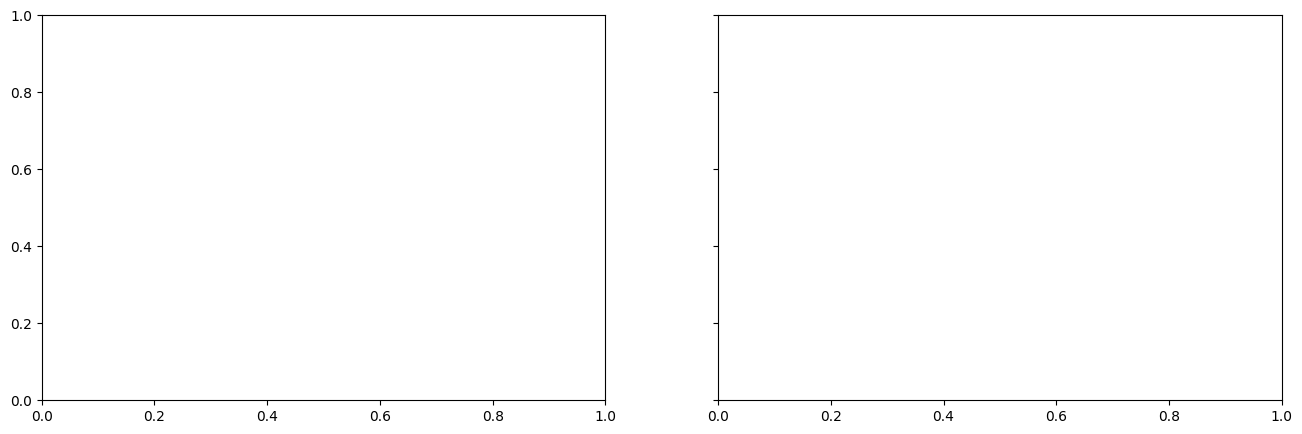

In [8]:
w_star_norm = norm(model.w_star)
w_star_dir = model.w_star / w_star_norm

times2, angles2, norm_diffs2, cos_wstar2, cos_wtilde2 = [], [], [], [], []

# Cell D: side-by-side merged comparison (model1 vs model2)
def normalize(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr - lo

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, t, ang, nd, ang_wt, ami_a, ami_n, ami_wt, label in [
    (ax1, times2, angles2, norm_diffs2, angle_wtilde2,
     argmin_angle, argmin_norm, argmin_angle_wtilde, f'Model 1 (seed=42), T_MAX={T_MAX}'),
    (ax2, times3, angles3, norm_diffs3, angle_wtilde3,
     argmin_angle3, argmin_norm3, argmin_angle_wtilde3, f'Model 2 (seed=123), T_MAX={T_MAX2}'),
]:
    ax.semilogx(t, normalize(ang),     color='steelblue',   linewidth=1.5, label=r'angle$(w_t/\|w_t\|, w^*/\|w^*\|)$')
    ax.semilogx(t, normalize(nd),      color='darkorange',  linewidth=1.5, label=r'$|\|w_t\| - \|w^*\||$')
    ax.semilogx(t, normalize(ang_wt),  color='mediumpurple',linewidth=1.5, label=r'angle$(w_t/\|w_t\|, \tilde{w})$')
    ax.axvline(ami_a,  color='steelblue',   linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(ami_n,  color='darkorange',  linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(ami_wt, color='mediumpurple',linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('GD iteration t (log scale)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax1.set_ylabel('Normalized value [0, 1]')
plt.suptitle('Side-by-side comparison: Model 1 vs Model 2', fontsize=13)
plt.tight_layout()
plt.savefig('angle_and_norm_comparison_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()